In [1]:
# Core Python
import os
import yaml

# CREDIT framework
from credit.datasets.era5_multistep_batcher import Predict_Dataset_Batcher
from credit.datasets.load_dataset_and_dataloader import BatchForecastLenDataLoader
from credit.parser import credit_main_parser
from credit.datasets import setup_data_loading
from credit.models import load_model
from credit.transforms import load_transforms, Normalize_ERA5_and_Forcing
from credit.datasets.era5_multistep_batcher import Predict_Dataset_Batcher
from credit.datasets.load_dataset_and_dataloader import BatchForecastLenDataLoader
from credit.transforms import Normalize_ERA5_and_Forcing
from tails.hurricane_genesis_ffs import HurricaneGenesisFFS, HurricaneGenesisFFS_CPS
from tails.cyclone_phase_tracker import CyclonePhaseTracker

import warnings
warnings.filterwarnings('ignore')

In [4]:
filepath = "/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/scheduler/" # "/glade/campaign/cisl/aiml/credit/models/one_degree_wxformer_6hr_ensemble/"
device = "cuda"

with open(os.path.join(filepath, "model.yml"), "r") as f:
    conf = yaml.safe_load(f)

conf['predict']['interp_pressure']['pressure_levels'] = [300., 600., 900.]
conf = credit_main_parser(conf, parse_training=False, parse_predict=True, print_summary=False)
data_config = setup_data_loading(conf)

ensemble_size = 1
conf["trainer"]["ensemble_size"] = ensemble_size
conf["predict"]["ensemble_size"] = ensemble_size

In [5]:
model = load_model(conf, load_weights=True).to(device)
model = model.eval()

In [6]:
# start = "2022-09-17 00:00:00"
# end   = "2022-09-27 00:00:00"

start = "2022-08-21 00:00:00"
end   = "2022-09-10 00:00:00"

forecast_times = [[start, end]]


dataset_params = dict(
    varname_upper_air=data_config["varname_upper_air"],
    varname_surface=data_config["varname_surface"],
    varname_dyn_forcing=data_config["varname_dyn_forcing"],
    varname_forcing=data_config["varname_forcing"],
    varname_static=data_config["varname_static"],
    varname_diagnostic=data_config["varname_diagnostic"],
    filenames=data_config["all_ERA_files"],
    filename_surface=data_config["surface_files"],
    filename_dyn_forcing=data_config["dyn_forcing_files"],
    filename_forcing=data_config["forcing_files"],
    filename_static=data_config["static_files"],
    filename_diagnostic=data_config["diagnostic_files"],
    lead_time_periods=6,
    history_len=data_config["history_len"],
    skip_periods=data_config["skip_periods"],
    transform=load_transforms(conf),
    sst_forcing=data_config["sst_forcing"],
    batch_size=1,
    rank=0,
    world_size=1,
)

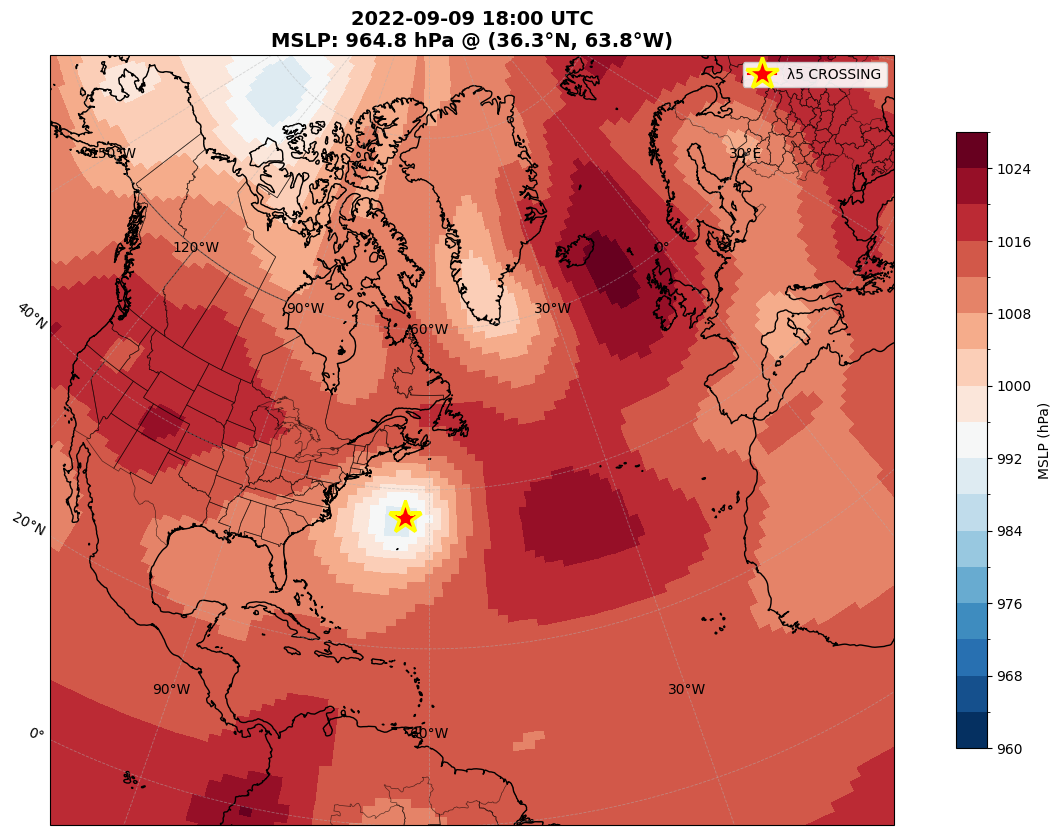

  → PNG: lambda5_config_0030_SC.png
  → SAVED: lambda5_config_0030_SC (964.8 hPa)
SUCCESS
✓ Target reached (30/30)

✓ Shooting complete
Attempts: 64
Successes: 30
Failures: 34
Configs saved: 30 (initial: 0, final: 30)
P(λ_4→λ_5) = 0.4688


FINAL RESULTS
Flux: 0.036461/day
P(λ_0→λ_1): 0.4110
P(λ_1→λ_2): 0.4286
P(λ_2→λ_3): 0.3371
P(λ_3→λ_4): 0.3947
P(λ_4→λ_5): 0.4688

P_FFS: 4.01e-04/day
P_direct: 0.00e+00/day

✓ Visualization disabled


In [8]:
initial_dataset = Predict_Dataset_Batcher(
    **dataset_params,
    fcst_datetime=forecast_times,
)

initial_loader = BatchForecastLenDataLoader(initial_dataset)

# Initialize FFS with tracking
ffs_base = HurricaneGenesisFFS(
    model=model,
    state_transformer=Normalize_ERA5_and_Forcing(conf),
    config=conf,
    initial_dataset=initial_dataset,
    dataset_params=dataset_params,
    interfaces=[1000, 988, 980, 975, 970],
    state_A=1008,
    state_B=965,
    max_attempts_without_success=200,
    output_dir="./ffs_tweaks",
    rank=0,
    world_size=1,
    worker_id=0,
)

ffs = HurricaneGenesisFFS_CPS(ffs_base)

# Enable visualization
ffs.enable_visualization()

# Run FFS (will show live MSLP plots and filter out preexisting storms)
ffs.run_ffs(initial_loader, n_flux_trials=50, n_shoot_trials=30)

# Disable when done
ffs.disable_visualization()